In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Dispositivo: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Hiperparámetros modelos
BATCH_SIZE = 64
NUM_EPOCHS = 20
LR         = 0.001

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = train_dataset.classes
print('Clases:', CLASSES)
print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')

100%|██████████| 170M/170M [00:04<00:00, 39.9MB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000 | Test: 10000


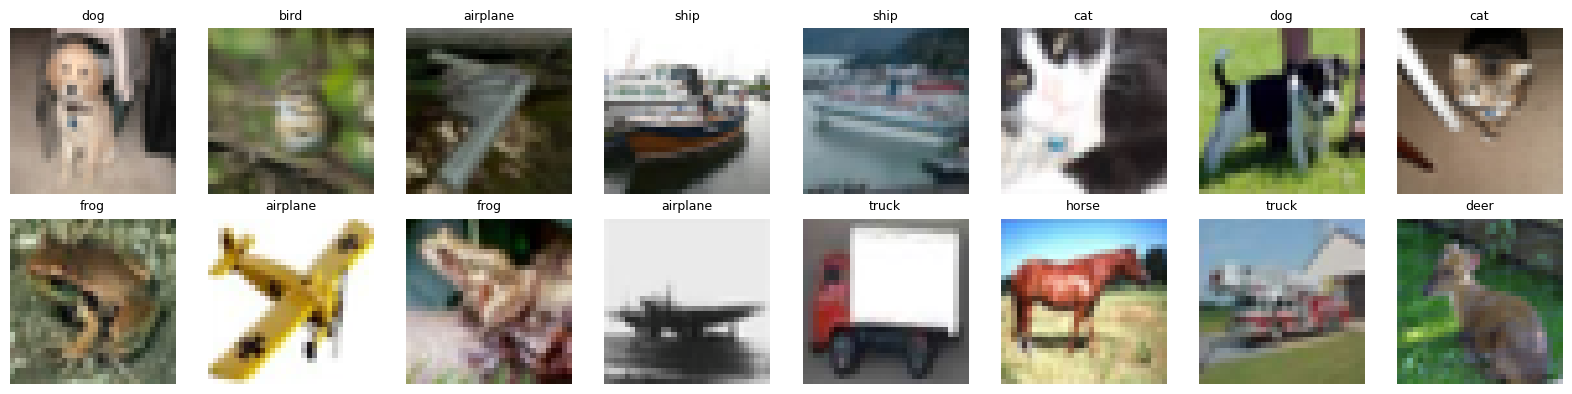

In [3]:
def imshow(img_tensor, title=None):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img = (img_tensor * std + mean).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title: plt.title(title, fontsize=9)
    plt.axis('off')

samples, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(samples[i], CLASSES[labels[i]])
plt.tight_layout()
plt.show()

In [4]:
# Modelo 1
class modelo1(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16×16×32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8×8×64
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# Modelo 2
class modelo2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),  # 16×16×32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),  # 8×8×64
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 4×4×128
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# Modelo 3
class modelo3(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            block(3,   64),   # 16×16×64
            block(64, 128),   # 8×8×128
            block(128, 256),  # 4×4×256
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2,2)),
            nn.Flatten(),
            nn.Linear(256*2*2, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

In [5]:
def train_model(model, name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {'train_loss': [], 'test_loss': []}

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'[{name}] Época {epoch}/{NUM_EPOCHS}', leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_dataset)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
        test_loss /= len(test_dataset)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        print(f'[{name}] epoca {epoch:2d} — Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}')

    return model, history

In [6]:
model_a, hist_a = train_model(modelo1(),  'modelo1')
model_b, hist_b = train_model(modelo2(), 'modelo2')
model_c, hist_c = train_model(modelo3(),   'modelo3')

[modelo1] Época 1/20:   0%|          | 0/782 [00:00<?, ?it/s]

[modelo1] epoca  1 — Train loss: 1.3785 | Test loss: 1.0633


[modelo1] Época 2/20:   0%|          | 0/782 [00:00<?, ?it/s]

[modelo1] epoca  2 — Train loss: 1.0015 | Test loss: 0.8958


[modelo1] Época 3/20:   0%|          | 0/782 [00:00<?, ?it/s]

...

[modelo3] epoca 18 — Train loss: 0.0701 | Test loss: 0.5657


[modelo3] Época 19/20:   0%|          | 0/782 [00:00<?, ?it/s]

[modelo3] epoca 19 — Train loss: 0.0597 | Test loss: 0.6382


[modelo3] Época 20/20:   0%|          | 0/782 [00:00<?, ?it/s]

[modelo3] epoca 20 — Train loss: 0.0551 | Test loss: 0.6357


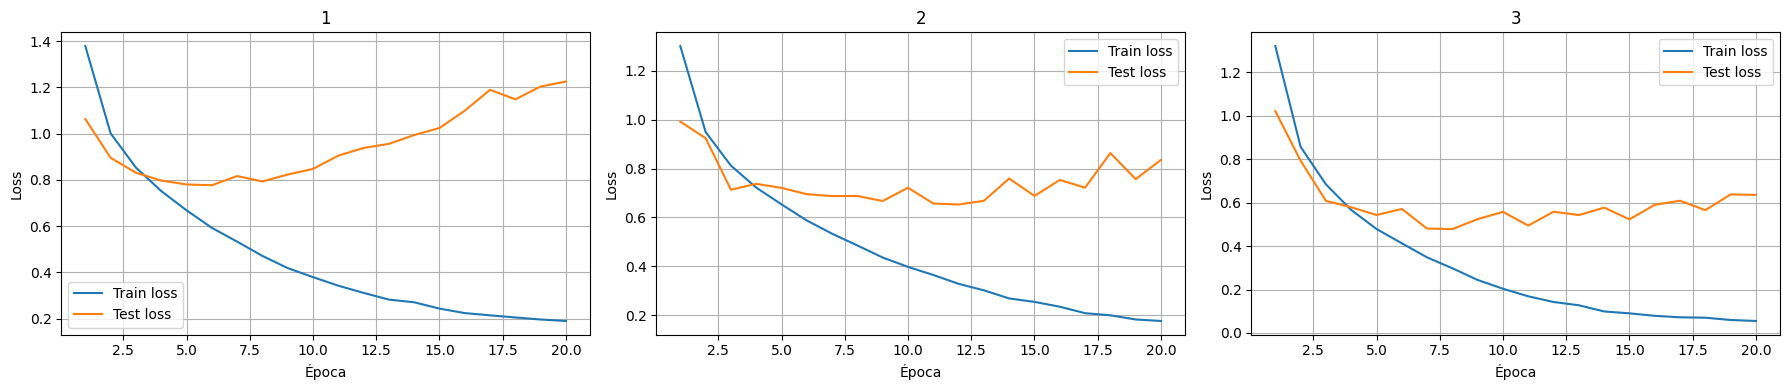

In [7]:
def plot_curves(histories, names):
    fig, axes = plt.subplots(1, len(histories), figsize=(6*len(histories), 4))
    for ax, hist, name in zip(axes, histories, names):
        epochs = range(1, len(hist['train_loss'])+1)
        ax.plot(epochs, hist['train_loss'], label='Train loss')
        ax.plot(epochs, hist['test_loss'],  label='Test loss')
        ax.set_title(name)
        ax.set_xlabel('Época')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_curves(
    [hist_a, hist_b, hist_c],
    ['1', '2', '3']
)

In [10]:
def evaluate(model, name):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100 * correct / total
    print(f'{name}: Accuracy = {acc:.2f}%')
    return acc

resultados = {'1': acc_a, '2': acc_b, '3': acc_c}
modelos    = {'1': model_a, '2': model_b, '3': model_c}

best_name  = max(resultados, key=resultados.get)
best_model = modelos[best_name]

print(f'\nMejor modelo: {best_name} con {resultados[best_name]:.2f}%')


Mejor modelo: 3 con 86.22%


## Reflexiones personales

Durante la actividad lo que mas me sorprendio fue el comportamiento de la test loss a lo largo del entrenamineot. Como train loss baja constante en los 3 modelos pero test loss sube mas en el primer modelo por el overfiting. Ya en el ultimo modelo usando dropou que apaga neurnas para evitar dependencia y forzar a aprender cosas mas generales asi como la normalizacion de cada batch para evitar esto. mas adeltante se pudiera poner data augmentation y un tpo de weight decay en el optimizador para reducir todavia mas el overfitting.